## Introducción PyTorch usando regresion lineal de ejemplo 


Para poder construir redes neuronales, desde muy sencillas a más complejas vamos a usar el framework de 'Dive into Deep Learning'. Este se inspira y toma mucho de la estructura de Pytorch con la particularidad que lo hace más amigable para correr en notebooks. 
Vamos a necesitar una serie de elementos: 
1. Modulo que contenga modelos, funciones de pérdida y métodos de optimización
2. Modulo de datos que tenga los data loaders para entrenar y validar
3. Combinar estas dos clases en una tercera clase Trainer que permite que se entrenen los modelos


¿Qué veremos acá?

Implementación de una regresión lineal desde 0 usando Pytorch. Para ver las propiedades de los tensores, que son y como se usan ver el notebook Intro_Tensores. 

¿Por qué esto es importante? 

Implementar las cosas desde 0 es la única manera de saber que esta pasando en realidad. No quiero que corran código que les dio un LLM (o google/stackoverflow) pero que no entienden por que funciona o no. Otra vez si solo hacen esto no hay diferencia entre ustedes y el LLM... 

Definición clave: 

Tensor: Un tensor es la estructura de datos fundamental en PyTorch (y en muchos frameworks de Deep Learning). Es una generalización de los vectores y matrices a dimensiones arbitrarias. Por ejemplo:
- Escalar → tensor 0‑D
- Vector → tensor 1‑D
- Matriz → tensor 2‑D
- Imágenes en lotes → tensor 4‑D (batch_size, canales, alto, ancho)
- Internamente es un arreglo multidimensional eficiente que puede residir en CPU o GPU.

Minibatch: En el entrenamiento vía gradiente descendente, en lugar de usar todo el dataset o un solo ejemplo por paso, agrupamos ejemplos en “minibatches” de tamaño batch_size. Cada minibatch:
- Produce un estimado del gradiente más estable que usar un solo ejemplo.
- Permite aprovechar paralelismo en GPU/CPU.
- Actúa como regularizador: introduce ruido estocástico que ayuda a escapar de mínimos locale

Epoca: Una época es una pasada completa por todo el conjunto de entrenamiento. Durante una época, cada ejemplo en el dataset se utiliza exactamente una vez para actualizar los parámetros de la red (a través de minibatches).  
  - Con `batch_size = 64` y, por ejemplo, 60 000 imágenes de MNIST, una época equivale a procesar 60 000 / 64 ≈ 938 minibatches.  
  - A menudo entrenamos varias épocas (p. ej., 5–10) para que el modelo vea los datos suficientes veces y converja.


Python class: en Python una clase es una plantilla para crear objetos. Esta compuesta de datos (atributos) y funcionalidades (métodos) que definen características y comportamientos del objeto en particular que estamos definiendo. Estan compuestas de:
- Declaración de la clase `def Miclase`: esto le avisa a python que lo que sigue es la creación de una clase con atributos y métodos
- Método constructor: `__init__`: se ejecuta automaticamente al crear un objeto, inicia el estado interno de la instancia, su primer parámetro siempre es `self` que hace referencia a el mismo, acá es donde se asignan atributos 
- Atributos: variables ligadas a la instancia del objeto 
- Métodos: funciones ligadas al objeto 
- Herencia: puedes crear clases que hereden atributos y objetos de otras clases 



### 1. Vamos a definir el modelo

¿Qué esta haciendo el código de acá abajo?

Definición de la clase de regresión lineal: 
- `class LinearRegression(nn.Module)`: acá definimos una clase con el nombre del modelo que queremos correr que va a heredar todo del modulo `nn.Module` esto nos da funcionalidad para registrar parámetros, serializar, etc
- `def __init`: el constructor recibe los parámetros en este caso el numero de inputs, la tasa de aprendizaje y la desviación estandar para los pesos 
- `super()` llama al constructor de `nn.Module` que prepara internamente que va a heredar estructuralmente de esta
- Almacenamos los hiperparámetros, guardamos como atributos de la instancia, para poder consultarlos más tarde 
- Hacemos lo mismo con los pesos y el sesgo
- `torch.normal(0.0, sigma, size=(num_inputs, 1))`: crea un tensor de (d,1) con valores sacados de una $\mathcal{N}(0,\sigma^2)$
- `torch.zeros(1)`: crea un tensor de forma (1,) inicializado en cero
- `nn.Parameter(...)`: envuelve los tensores para indicarle a Pytorch que debe incluir w y b en la lista de parámetros y rastrear los gradientes `requires_grad=True` es el default para este metodo 
- ¿Por qué necesitamos `nn.Parameter`? Sin esto, PyTorch no sabría qué tensores actualizar durante el entrenamiento.


Método `forward`:
- recibe un tensor X de tamaño `(batch_size, num_inputs)` donde cada renglón es un vector de características
- `torch.matmul(X, self.w)` realiza la operación Xw, donde las dimensiones de  X son (batch_size, d) y las de w es (d, 1), resultando en un tensor de (batch_size, 1)
- `+ self.b` suma el sesgo que es de dimension (1,) pero el broadcast de torhc lo vuelve de (batch_size, 1)
- Nos regresa la predicción $\hat{y}$ para cada minibatch 

Método `loss`: 
- Recibe como parámetros la estimación y_hat y el valor real y, los dos son tensores de (batch_size, 1)
- Calcula la pérdidida cuadrática para cada y
- Regresa la media de la pérdida sobre todas las y's 

Método `configure_optimizers`: 
- Crea una instancia de nuestro optimizador SGD
- Le pasamos los parámetros y la tasa de aprendizaje 

In [15]:
# paquete central de PyTorch; contiene tensores y las operaciones sobre ellos.
import torch
# módulos y capas de red (e.g., Linear, ReLU, CrossEntropyLoss).
import torch.nn as nn

class LinearRegression(nn.Module):
    """Modelo de regresión lineal implementado desde cero en PyTorch"""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super(LinearRegression, self).__init__()
        # Guardamos los hiperparámetros “a mano”, lo que le pasamos se asigna a la instancia en particular
        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma
        # Parámetros del modelo: pesos y sesgo
        # nn.Parameter indica a PyTorch que debe calcular gradientes sobre este tensor
        self.w = nn.Parameter(
            torch.normal(0.0, sigma, size=(num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )
    
    def forward(self, X):
        """ Calcula la estimación y_hat dados los paramétros actuales y X"""
        return torch.matmul(X, self.w) + self.b
    
    def loss(self, y_hat, y):
        """Calcula la pérdida de regresión lineal
        y devuelve el valor medio sobre el minibatch.
        """
        # 1) Error al cuadrado, escalado por 1/2
        l = (y_hat - y) ** 2 / 2
        # 2) Promedio sobre todas las muestras
        return l.mean()
    
    def configure_optimizers(self):
        """
        Crea y devuelve el optimizador SGD configurado con nuestros parámetros.
        """
        # Pasamos los parámetros w y b al optimizador y la lr
        return SGD([self.w, self.b], self.lr)

Definimos nuestro algorítimo de optimización en este caso vamos a usar minibatch SGD.

Clase SGD: 
- toma como parámetros la lista de tensores `nn.Parameter` que queremos optimizar en este caso w y b y la tasa de aprendizaje `lr`
- Método `step`: `p.grad` contiene el gradiente calculado tras `loss.backward()` y actualiza el valor de p restando a los parámetros actuales la tasa de aprendizaje menos el gradiente 
- Método `zero_grad`: Antes de cada pasada forward→backward, limpiamos los gradientes previos; de lo contrario se acumularían y nos quedamos sin memoria!

In [13]:
class SGD:
    """Descenso de gradiente estocástico por minibatches."""
    def __init__(self, params, lr):
        # params: iterable de nn.Parameter
        self.params = list(params)
        self.lr = lr

    def step(self):
        """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
        for p in self.params:
            # p.grad es el gradiente calculado en backward()
            p.data -= self.lr * p.grad

    def zero_grad(self):
        """Pone a cero todos los gradientes para la siguiente iteración."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


OK y ahora como usamos todo esto para entrenar un modelo. 

Algunas definicion que necesitamos para entender que está pasando acá abajo: 
- `TensorDataset`: toma tensores alineados (aquí, X y y) y los empaqueta como un conjunto de pares $(X_i,y_i)$, permite tratar los tensores como un dataset de PyTorch
- `DataLoader`: envuelve un dataset o un tensorDataset para generar minibatches durante el entrenamiento o la validación, los parámetros principales son batch_size, shuffle (si va a barajear el dataset cada que comienza una nueva época) útil en el entrenamiento pero no en la validación. 

¿Qué hace este código? 

- Genera 1000 ejemplos sintéticos 
- Crea un `TensorDataset(X, y)`
- Parte ese dataset en $80\%$ entrenamiento (800 ejemplos) y $20\%$ validación (200 ejemplos) con `random_split`
- Crea dos DataLoader: train y val uno con `shuffle=True` para aleatorizar los minibatches y el otro no 
- En cada época: en la fase de entrenamiento itera sobre train y actualiza parámetros, en la fase de validación itera sobre val para calcular la pérdida, ya no saca los gradientes
- Almacena las pérdidas promedio de entrenamiento y validación por epoch en listas.
- Grafica ambas series de pérdidas vs. epoch usando Matplotlib, con la curva de entrenamiento y la de validación para comparar convergencia y posible sobreajuste

Error en w: tensor([ 0.0013, -0.0015])
Error en b: tensor([0.0022])


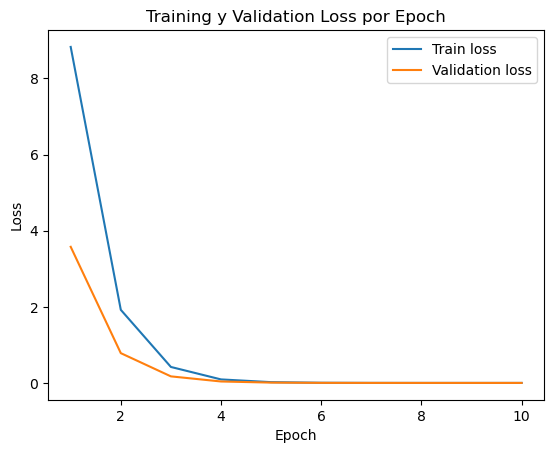

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

# 1) Creamos datos sinteticos para probar nuestra infra: 
def synthetic_regression_data(w, b, num_samples=1000):
    """Genera X ~ N(0,1) y y = Xw + b + ruido."""
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1, 1) + b
    y += torch.randn_like(y) * 0.01  # agrega ruido a nuestros datos 
    return X, y

# 2) Preparamos datos y dataloaders
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)


# 3) Crear TensorDataset y dividir en train/validation
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 4) Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 5) Instanciamos el modelo y el optimizador
model = LinearRegression(num_inputs = 2, lr = 0.03)
optim = model.configure_optimizers()  # nuestra clase SGD

# 6) Entrenamiento: 
num_epochs = 10
# Listas para almacenar la pérdida media de cada epoch
train_losses, val_losses = [], []
for epoch in range(1, num_epochs + 1):
    # activa el modo entrenamiento (acá no lo necesitamos porque lo estamos haciendo a mano, pero es buena práctica)
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model(Xb)
        loss = model.loss(y_hat, yb)
        optim.zero_grad()
        loss.backward()
        optim.step()
        total_train += loss.item() * yb.shape[0]
        count_train += yb.shape[0]
    train_losses.append(total_train / count_train)

    # Fase de validación
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]
    val_losses.append(total_val / count_val)

# 7) Evaluación final de los parámetros aprendidos
with torch.no_grad():
    est_w = model.w.reshape(true_w.shape)
    est_b = model.b
    print("Error en w:", true_w - est_w)
    print("Error en b:", true_b - est_b)

# 8) Graficar pérdidas
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch')
plt.show()
